In [1]:
import torch
from monai.losses import DiceCELoss
from tqdm.notebook import tqdm
from src.data_utils import download_data, build_paths_df
from src.preprocessing import split_mask, split_dataset, build_loader
from src.get_models import get_unet_plus_plus, get_unet_plus_plus_for_refinement
from src.train_model import train_model, FocalTverskyLoss
from src.evaluate_model import find_optim_threshold, groups_metrics_reports, best_worst_patient_segmentation, confusion_matrix, lesion_wise_metrics
from src.visualization import visualize_mri_with_two_mask

## Формируем маски крупных и мелких очагов

In [2]:
# Путь к датасету
dataset_dir = download_data()

In [3]:
# Формируем датафрейм путей к маскам
paths_df = build_paths_df(dataset_dir)
masks_df = paths_df[paths_df['label'] == 'mask']

In [4]:
# Формируем и сохраняем новые маски для каждого пациента
for row in tqdm(masks_df.itertuples(), total=len(masks_df)):
    split_mask(row.file_path, row.patient_id)

  0%|          | 0/250 [00:00<?, ?it/s]

## Формирование лоадеров оригинальных масок и масок крупных/мелких очагов

In [2]:
# Разбиваем данные на подвыборки
train_df, val_df, test_df = split_dataset(to_ensemble=True)

In [3]:
# Создаем лоадеры для оригинальных масок
all_lesions_train = build_loader(train_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=True, batch_size=1, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
all_lesions_val = build_loader(val_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)
all_lesions_test = build_loader(test_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)

In [4]:
# Создаем лоадеры для масок крупных очагов
large_lesions_train = build_loader(train_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='large_mask', augmentations=True, batch_size=1, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
large_lesions_val = build_loader(val_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='large_mask', augmentations=False, batch_size=1, shuffle=True)
large_lesions_test = build_loader(test_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='large_mask', augmentations=False, batch_size=1, shuffle=True)

In [5]:
# Создаем лоадеры для масок мелких очагов
small_lesions_train = build_loader(train_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='small_mask', augmentations=True, batch_size=1, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
small_lesions_val = build_loader(val_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='small_mask', augmentations=False, batch_size=1, shuffle=True)
small_lesions_test = build_loader(test_df, protocols_list=['dwi', 'adc', 'flair'], mask_label='small_mask', augmentations=False, batch_size=1, shuffle=True)

## Обучение модели сегментации крупных очагов

### Обучение с ранее подобранными параметрами

In [7]:
# Инициализация модели, функции потерь, оптимизатора и планировщика
unet_plus_plus, criterion, optimizer, scheduler = get_unet_plus_plus(in_channels=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


Epoch 76 of 200
train loss: 	0.424077
val loss: 	0.434327
train dice: 			0.61
val dice: 			0.57


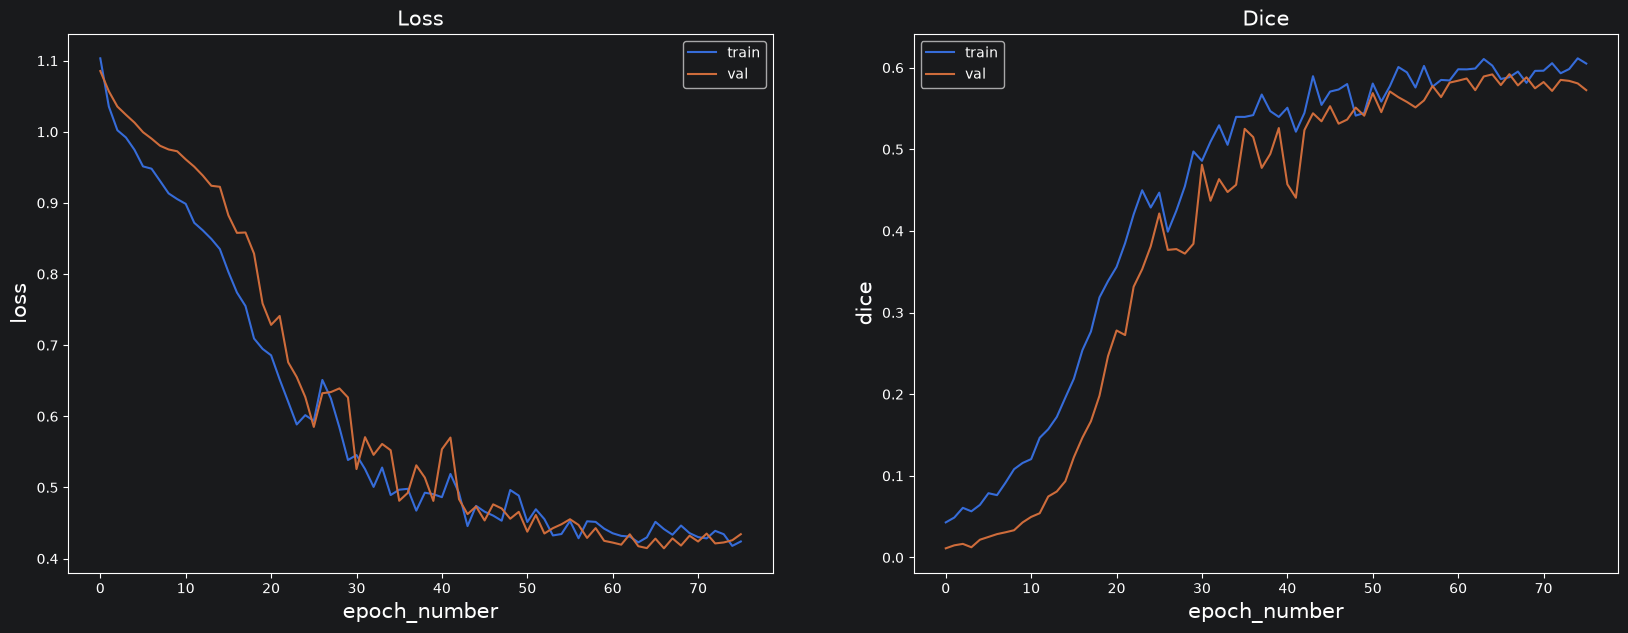

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [8]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, large_lesions_train, large_lesions_val,
    weights_dir_name='large_lesions_model', n_epochs=200, patience=10
)

In [6]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='large_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [7]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, large_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
14,0.8,1.0,0.925926,0.961538,0.634453,0.510149,31.827596,0.954358,1.250115e-14


In [8]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [9]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.490520,0.171752,0.385363,0.138218,10.473483,14.538733
1,multiple_only_large_lesion,4,0.476968,0.223681,0.383989,0.192959,8.926959,14.589531
2,one_large_lesion,4,0.806233,0.105001,0.685714,0.157029,0.853553,0.601605


Несмотря на то, что данная модель обучалась сегментировать только крупные очаги ишемического поражения, она показывает худшее качество сегментации, чем модель обученная на очагах всех размеров.

### Заменим функию потерь на DiceCELoss

In [7]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [8]:
# Инициализации функции потерь, оптимизатора и планировщика
criterion = DiceCELoss(sigmoid=True, include_background=True, lambda_dice=1.0, lambda_ce=1.0)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Epoch 75 of 200
train loss: 	0.427083
val loss: 	0.422841
train dice: 			0.61
val dice: 			0.58


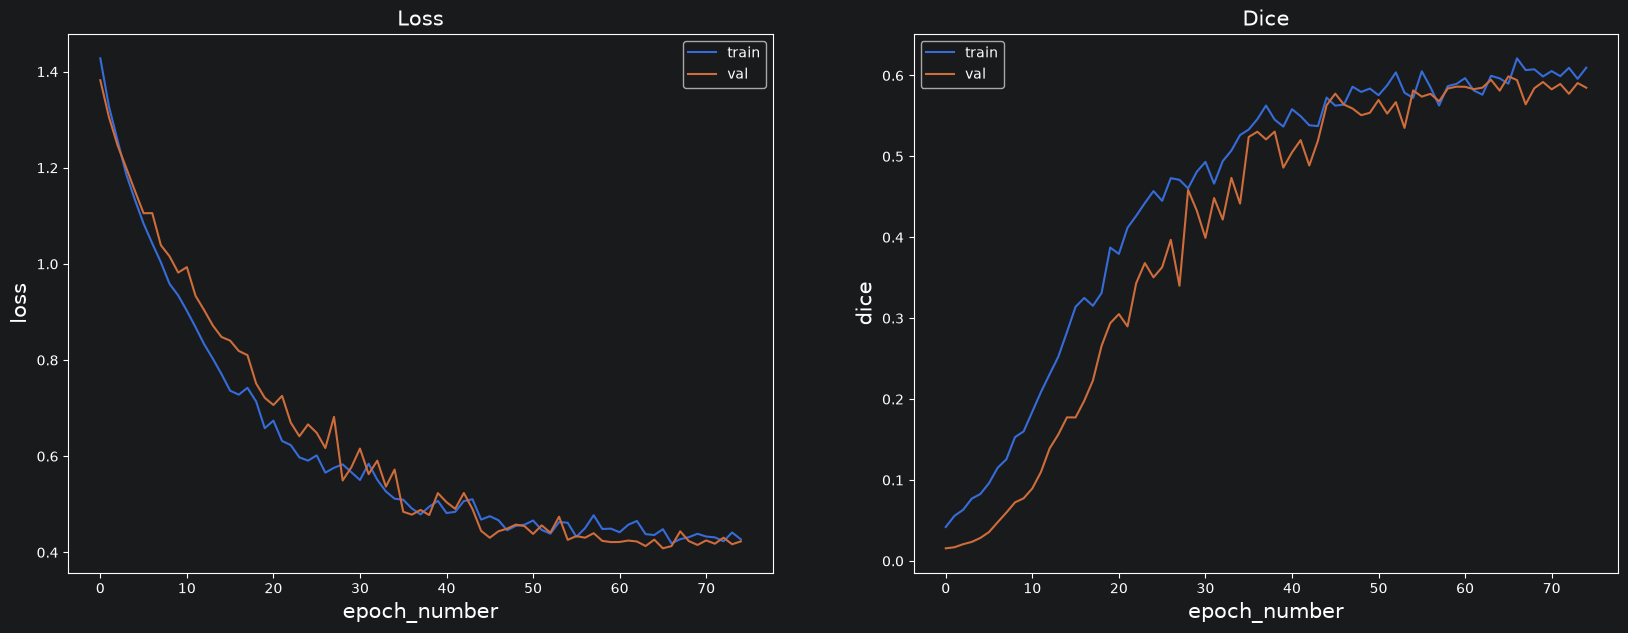

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [9]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, large_lesions_train, large_lesions_val,
    weights_dir_name='DiceCE_large_lesions_model', n_epochs=200, patience=10
)

In [10]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='DiceCE_large_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [11]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, large_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
14,0.8,0.96,0.888889,0.923077,0.652405,0.531987,23.892664,0.936956,6.445026e-13


In [12]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [13]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.484276,0.192143,0.383750,0.156772,11.564899,16.276487
1,multiple_only_large_lesion,4,0.506707,0.274659,0.408030,0.226697,8.533799,14.240738
2,one_large_lesion,4,0.805526,0.105328,0.684797,0.157744,0.893283,0.653944


Замена функции потерь на DiceCEloss привела к общему увеличению качеству сегментации, однако снизило способность модели обнаруживать поражение

### Увеличим вес поражения для функции потерь

In [43]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [46]:
# Инициализации функции потерь, оптимизатора и планировщика
criterion = DiceCELoss(sigmoid=True, include_background=True, weight=torch.tensor([3.0]).to('cuda'), lambda_dice=1.5, lambda_ce=1.0)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Epoch 81 of 200
train loss: 	0.633181
val loss: 	0.582124
train dice: 			0.62
val dice: 			0.62


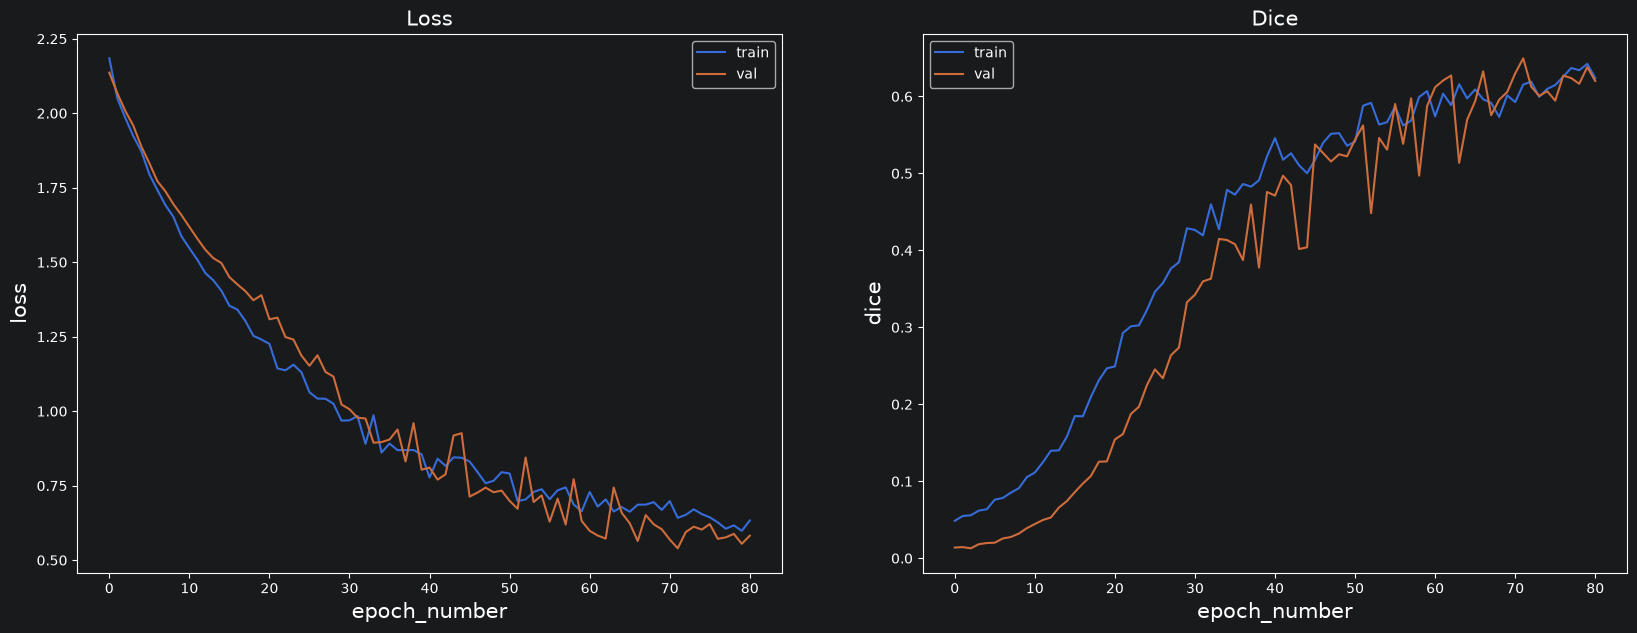

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [47]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, large_lesions_train, large_lesions_val,
    weights_dir_name='DiceCE_w3_large_lesions_model', n_epochs=200, patience=10
)

In [14]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='DiceCE_w3_large_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [15]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, large_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
13,0.75,1.0,0.925926,0.961538,0.647413,0.524192,28.27833,0.955274,9.751366e-15


In [16]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [17]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.487715,0.168726,0.382995,0.136362,9.998166,14.632327
1,multiple_only_large_lesion,4,0.531837,0.283480,0.433728,0.242102,17.179523,18.265754
2,one_large_lesion,4,0.780447,0.138920,0.656844,0.198266,0.750000,0.500000


Увеличения веса поражения до 3 привело, по качеству, к компромису между двумя прошлыми моделями, сохранив способность обнаруживать поражения и повысив качество сегментации, по сравнению с моделью, обученной с DiceFocalloss

## Обучение модели сегментации мелких очагов

### Обучение с ранее подобранными параметрами

In [78]:
# Инициализация модели, функции потерь, оптимизатора и планировщика
unet_plus_plus, criterion, optimizer, scheduler = get_unet_plus_plus(in_channels=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


Epoch 48 of 200
train loss: 	1.000485
val loss: 	1.000616
train dice: 			0.00
val dice: 			0.00


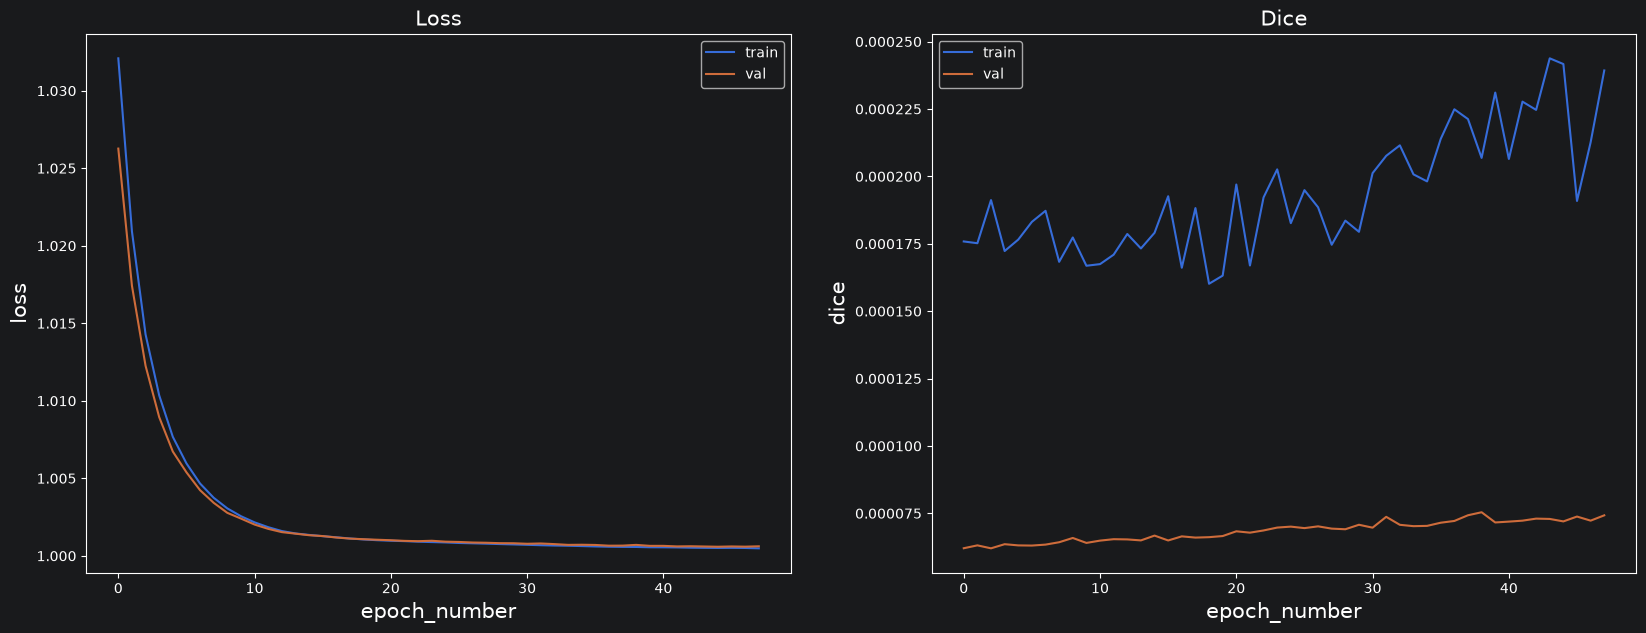

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [80]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, small_lesions_train, small_lesions_val,
    weights_dir_name='small_lesions_model', n_epochs=200, patience=10
)

In [30]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='small_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [19]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, small_lesions_test)
thresholds_metrics

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\evaluate_model.py:218: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_coef, spearman_p_value = spearmanr(true_volumes, pred_volumes)


,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
3,0.25,0.0,0.0,0.0,0.333333,0.333333,20.686055,0.476624,0.011954


In [20]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\evaluate_model.py:538: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_coef, spearman_p_value = spearmanr(true_volumes, pred_volumes)
C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\evaluate_model.py:538: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_coef, spearman_p_value = spearmanr(true_volumes, pred_volumes)


In [21]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.0,0.0,0.0,0.0,0.0,0.0
4,multiple_only_small_lesion,1,0.0,NaN,0.0,NaN,0.0,NaN


Модель, обученная только на очагах малого объема, показала неспособность к их сегментации, получая наименьший лосс при полном отсутствии сегментации

### Попробуем заменить функцию потерь на FocalTverskyLoss

In [43]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [44]:
# Инициализация функции потерь, оптимизатора и планировщика
criterion = FocalTverskyLoss(alpha=0.5, beta=0.5, gamma=2.0, smooth=1e-6)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Epoch 90 of 200
train loss: 	0.803497
val loss: 	0.849298
train dice: 			0.12
val dice: 			0.09


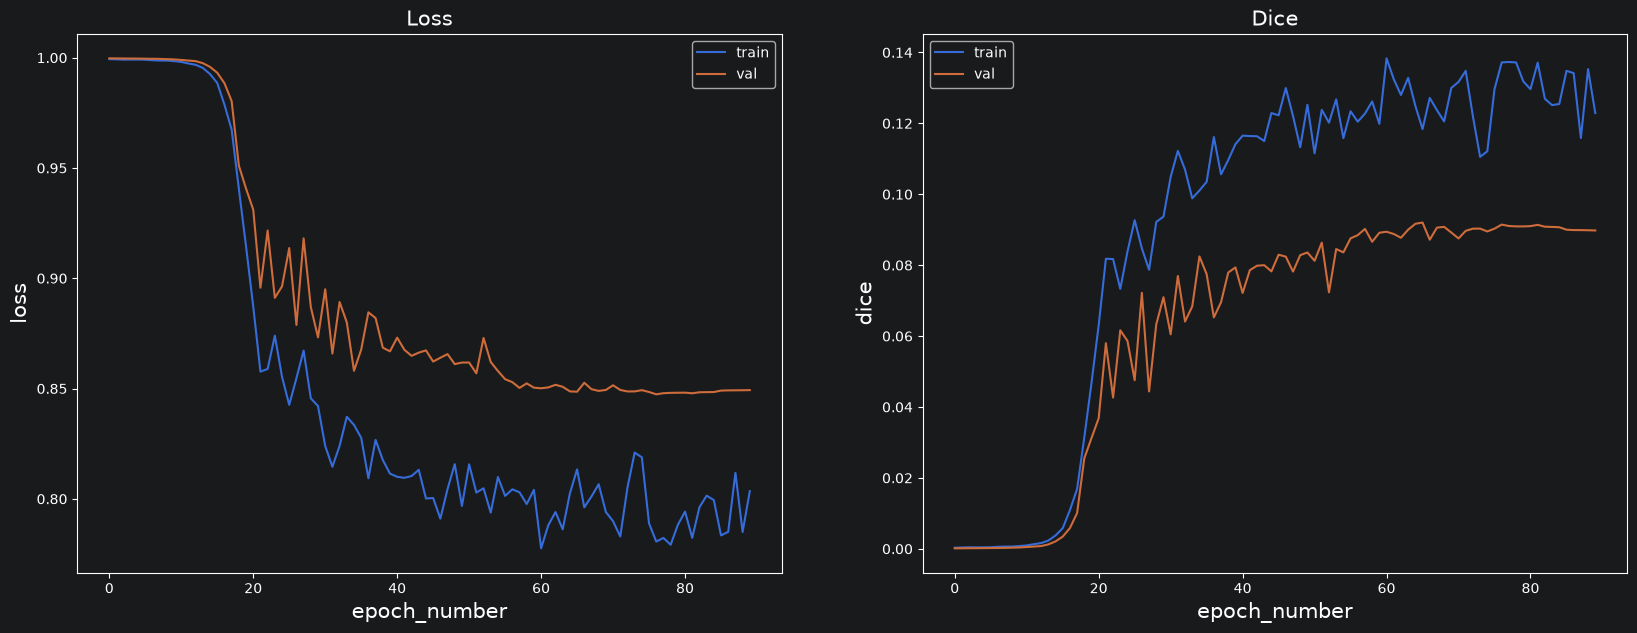

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [45]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, small_lesions_train, small_lesions_val,
    weights_dir_name='FocalTversky_lesions_model', n_epochs=200, patience=25
)

In [46]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='FocalTversky_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [47]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, small_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
15,0.85,0.388889,0.259259,0.311111,0.095245,0.056998,69.76611,0.70001,0.000048


In [48]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [49]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.184185,0.213335,0.135756,0.164604,1.361485,1.380786
4,multiple_only_small_lesion,1,0.000000,NaN,0.000000,NaN,0.000000,NaN


Замена функции потерь на DiceFocalloss позволило модели начать обучаться и сегментировать мелкие ишемические очаги

### Увеличим штраф за ложноотрицательную сегментации функции потерь

In [ ]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

In [ ]:
# Инициализация функции потерь, оптимизатора и планировщика
criterion = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=2.0, smooth=1e-6)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Epoch 89 of 200
train loss: 	0.783218
val loss: 	0.850843
train dice: 			0.12
val dice: 			0.07


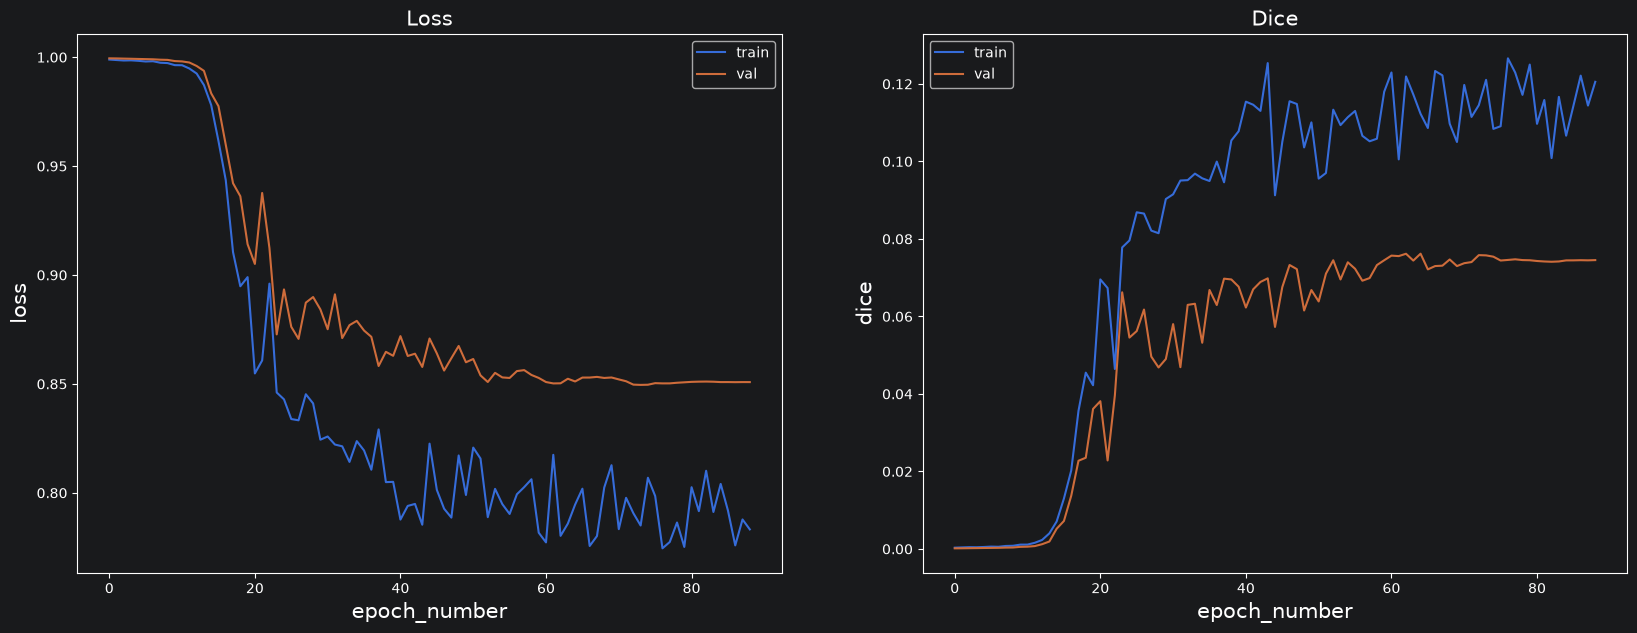

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [36]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, small_lesions_train, small_lesions_val,
    weights_dir_name='FocalTversky_beta7_lesions_model', n_epochs=200, patience=25
)

In [50]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='FocalTversky_beta7_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [51]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, small_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
17,0.95,0.333333,0.222222,0.266667,0.082989,0.047743,81.291509,0.654758,0.000211


In [52]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [53]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.187347,0.189591,0.134062,0.141819,1.476592,1.48048
4,multiple_only_small_lesion,1,0.000000,NaN,0.000000,NaN,0.000000,NaN


### Увеличим штраф за ложноположительную сегментации функции потерь

In [ ]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

In [28]:
# Инициализация функции потерь, оптимизатора и планировщика
criterion = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=4.0, smooth=1e-6)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Epoch 86 of 200
train loss: 	0.798227
val loss: 	0.841488
train dice: 			0.12
val dice: 			0.09


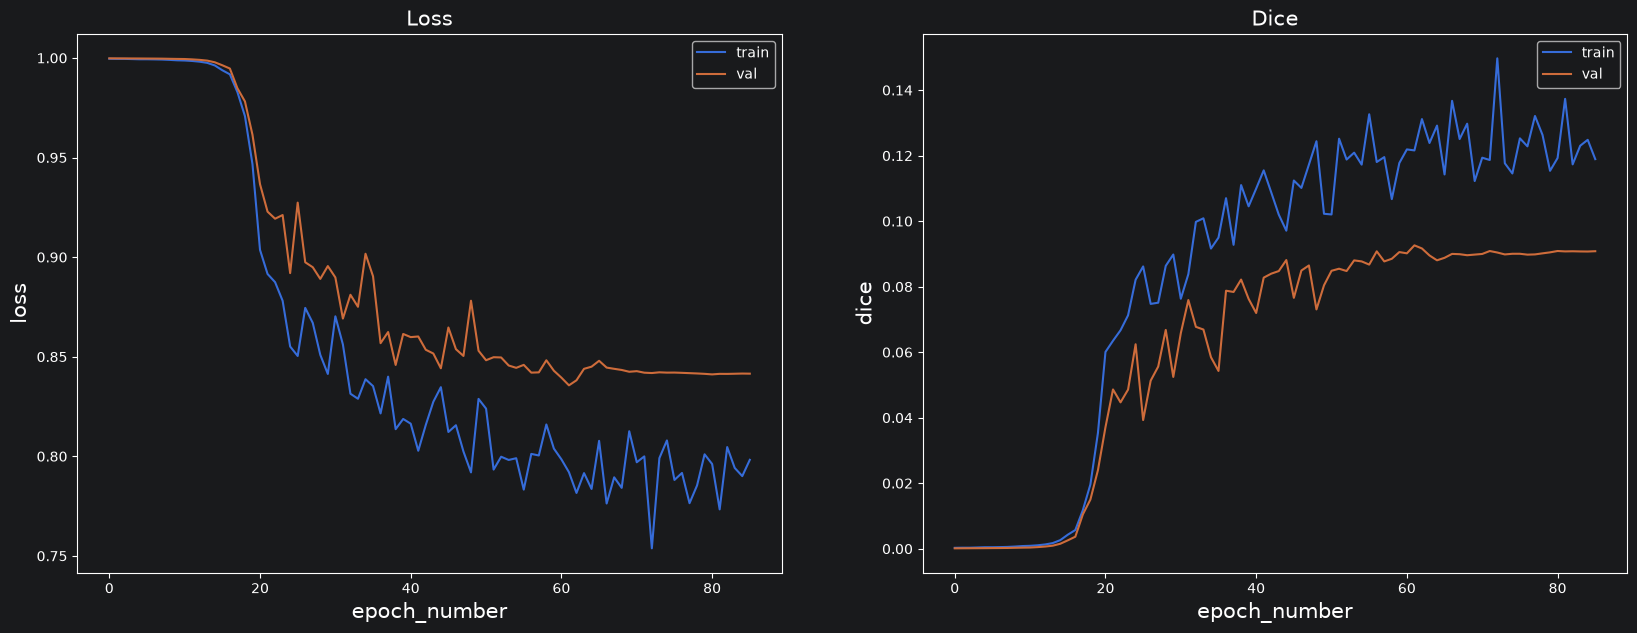

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [20]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, small_lesions_train, small_lesions_val,
    weights_dir_name='FocalTversky_alpha7_lesions_model', n_epochs=200, patience=25
)

In [38]:
# Инициализация модели с загрузкой обученных весов
unet_plus_plus = get_unet_plus_plus(in_channels=3, weights_dir='FocalTversky_alpha7_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [27]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, small_lesions_test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
15,0.85,0.444444,0.307692,0.363636,0.137287,0.097127,60.574694,0.756136,0.000005


In [28]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [29]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.178768,0.201648,0.133758,0.15531,0.96076,0.810759
4,multiple_only_small_lesion,1,0.000000,NaN,0.000000,NaN,0.00000,NaN


## Итоговая оценка ансамбля моделей

In [6]:
large_lesions_model = get_unet_plus_plus(in_channels=3, weights_dir='DiceCE_w3_large_lesions_model')
small_lesions_model = get_unet_plus_plus(in_channels=3, weights_dir='FocalTversky_alpha7_lesions_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).
BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [28]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(large_lesions_model, all_lesions_test, small_lesions_model)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
13,0.75,0.961538,0.925926,0.943396,0.644933,0.519987,31.34859,0.955433,9.333716e-15


In [29]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = groups_metrics_reports(large_lesions_model,  test_df, ['dwi', 'adc', 'flair'], small_lesions_model, threshold=best_threshold)

In [30]:
all_lesion_metrics

,patient_group,patient_count,recall,precision,f1,spearman_coef,spearman_p_value,all_dice,all_dice_std,all_iou,all_iou_std,all_hd,all_hd_std
0,multiple_mixed_lesion,17,1.0,1.0,1.0,0.936275,3.283419e-08,0.597929,0.143913,0.461780,0.134803,9.028326,13.825805
1,multiple_only_large_lesion,4,1.0,1.0,1.0,0.800000,2.000000e-01,0.663679,0.279274,0.546119,0.271815,16.941736,18.055653
2,one_large_lesion,4,1.0,1.0,1.0,1.000000,0.000000e+00,0.780447,0.138920,0.656844,0.198266,0.750000,0.500000
3,no_lesion,1,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
4,multiple_only_small_lesion,1,0.0,0.0,0.0,NaN,NaN,0.276583,NaN,0.183347,NaN,2.437582,NaN


In [31]:
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.625002,0.145341,0.489589,0.141833,9.969270,14.637411
1,multiple_only_large_lesion,4,0.663679,0.279274,0.546119,0.271815,16.941736,18.055653
2,one_large_lesion,4,0.780447,0.138920,0.656844,0.198266,0.750000,0.500000


In [32]:
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.364355,0.293724,0.268336,0.227379,3.035887,7.563335
4,multiple_only_small_lesion,1,0.276583,NaN,0.183347,NaN,2.437582,NaN


In [8]:
confusion_matrix_df = confusion_matrix(test_df, large_lesions_model, small_lesions_model, threshold=best_threshold)
confusion_matrix_df

,group,tp,fp,fn,tn
0,multiple_mixed_lesion,17,0,0,0
1,multiple_only_large_lesion,4,0,0,0
2,one_large_lesion,4,0,0,0
3,no_lesion,0,1,0,0
4,multiple_only_small_lesion,0,1,1,0


In [9]:
confusion_matrix_df = confusion_matrix(test_df, large_lesions_model, small_lesions_model, threshold=best_threshold, overlap_threshold=0)
confusion_matrix_df

,group,tp,fp,fn,tn
0,multiple_mixed_lesion,17,0,0,0
1,multiple_only_large_lesion,4,0,0,0
2,one_large_lesion,4,0,0,0
3,no_lesion,0,1,0,0
4,multiple_only_small_lesion,1,0,0,0


In [10]:
f1_matrix = lesion_wise_metrics(test_df, large_lesions_model, small_lesions_model, threshold=best_threshold)
f1_matrix

,group,f1,precision,recall
0,multiple_mixed_lesion,0.386543,0.323571,0.529056
1,multiple_only_large_lesion,0.309878,0.201705,0.708333
2,one_large_lesion,0.162103,0.089128,1.000000
3,no_lesion,0.000000,0.000000,0.000000
4,multiple_only_small_lesion,0.083333,0.045455,0.500000


In [14]:
((17 * 0.386543) + (4 * 0.309878) + (4 * 0.162103) + (1 * 0.083333)) / (17 + 4 + 4 + 1)

0.32855723076923077

In [11]:
f1_matrix = lesion_wise_metrics(test_df, large_lesions_model, small_lesions_model, threshold=best_threshold, overlap_threshold=0)
f1_matrix

,group,f1,precision,recall
0,multiple_mixed_lesion,0.418823,0.350760,0.577568
1,multiple_only_large_lesion,0.355332,0.232955,0.791667
2,one_large_lesion,0.162103,0.089128,1.000000
3,no_lesion,0.000000,0.000000,0.000000
4,multiple_only_small_lesion,0.083333,0.045455,0.500000


In [ ]:
large_lesions_model = get_unet_plus_plus(in_channels=3, weights_dir='DiceCE_w3_large_lesions_model')
small_lesions_model = get_unet_plus_plus(in_channels=3, weights_dir='FocalTversky_alpha7_lesions_model')

In [ ]:
# Выделение пациентов с лучшими и худшими метриками Dice
best_dice_patients_idx, worst_dice_patients_idx = best_worst_patient_segmentation(test_df, patients_dice_df)

#### Лучшие случаи сегментации

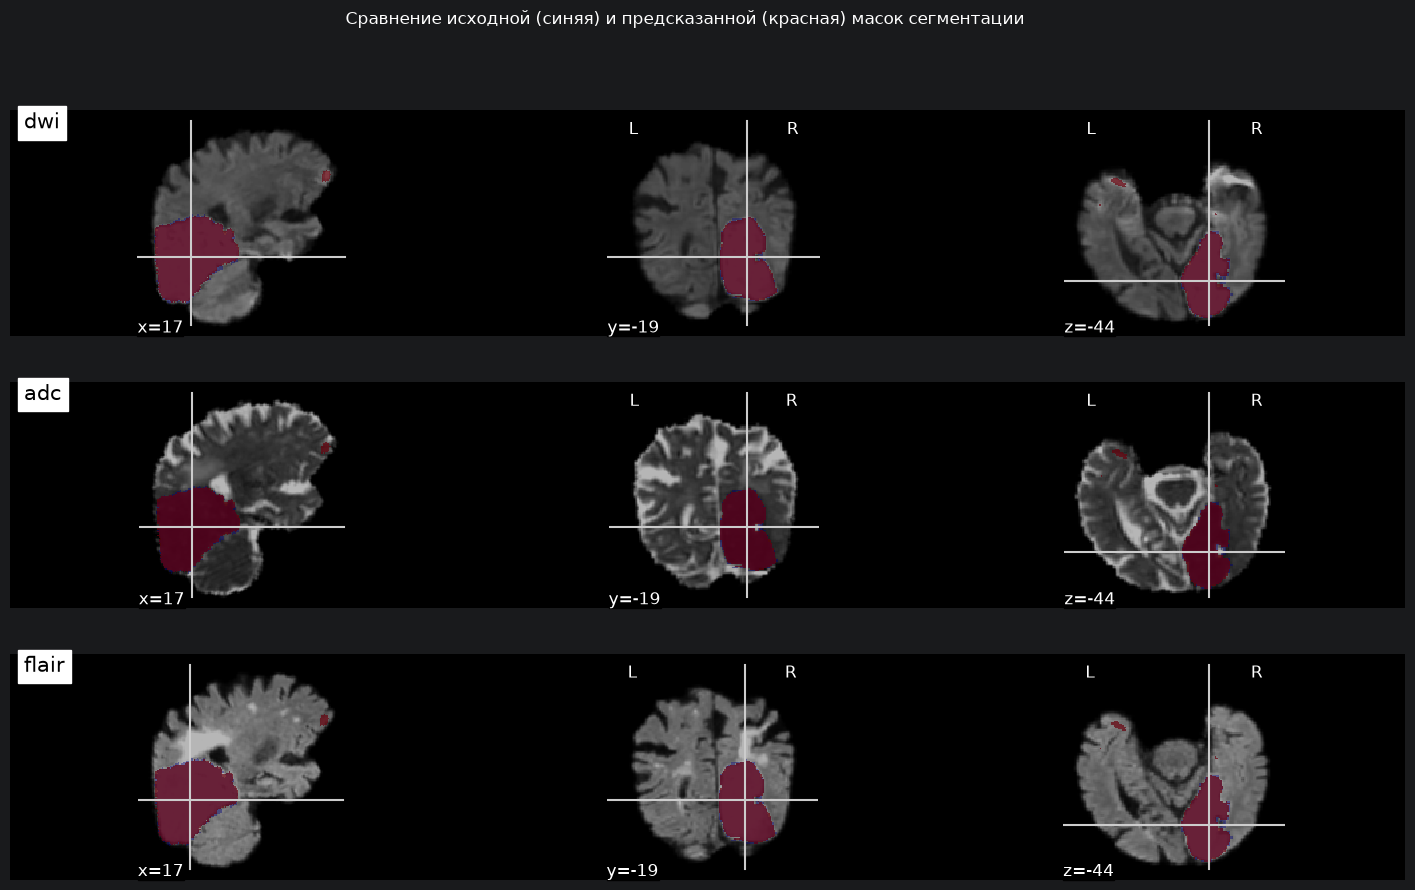

In [8]:
visualize_mri_with_two_mask(large_lesions_model, test_df, best_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)

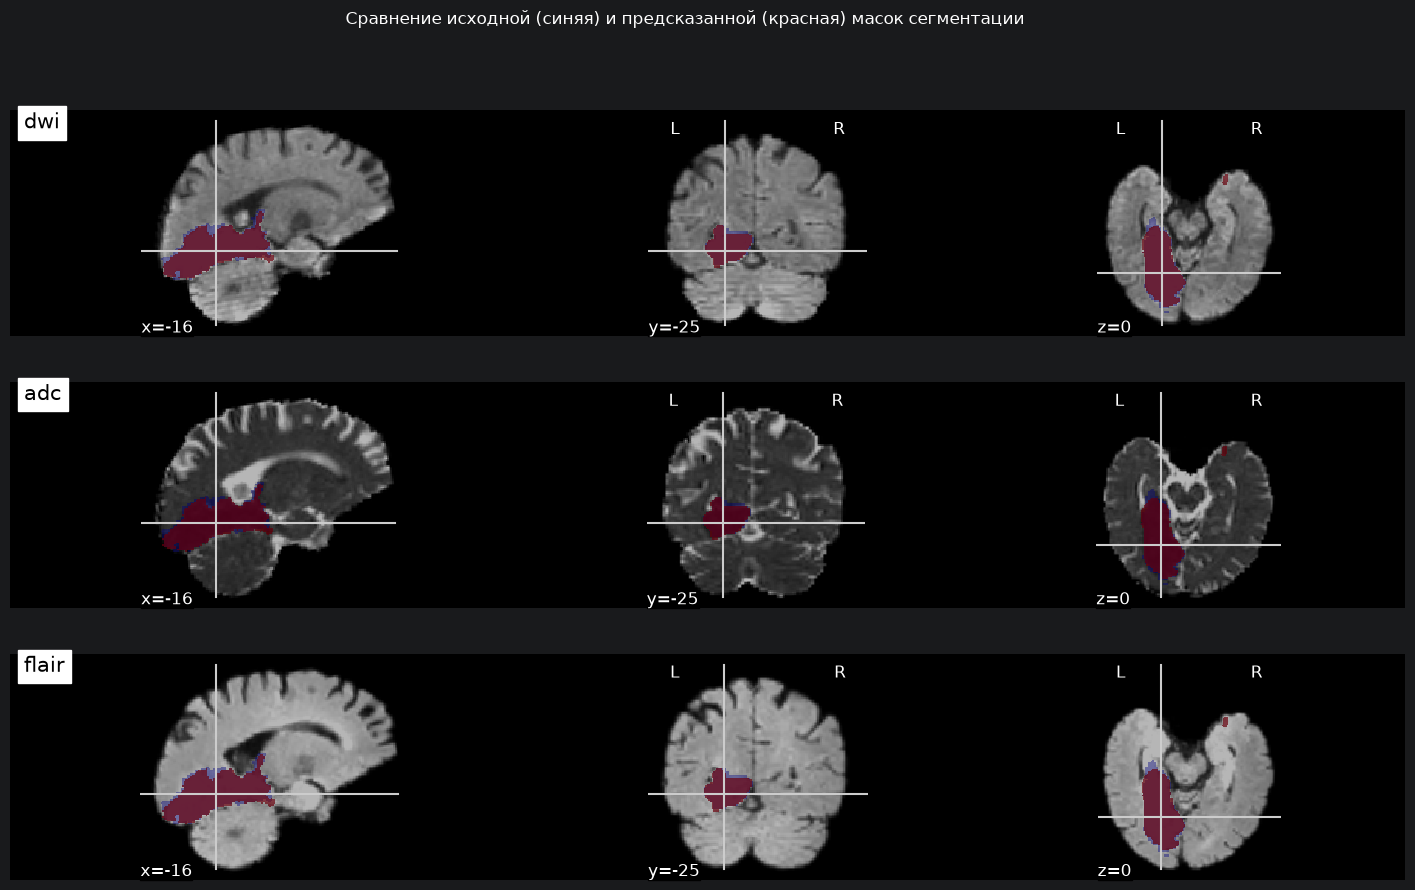

In [9]:
visualize_mri_with_two_mask(large_lesions_model, test_df, best_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)

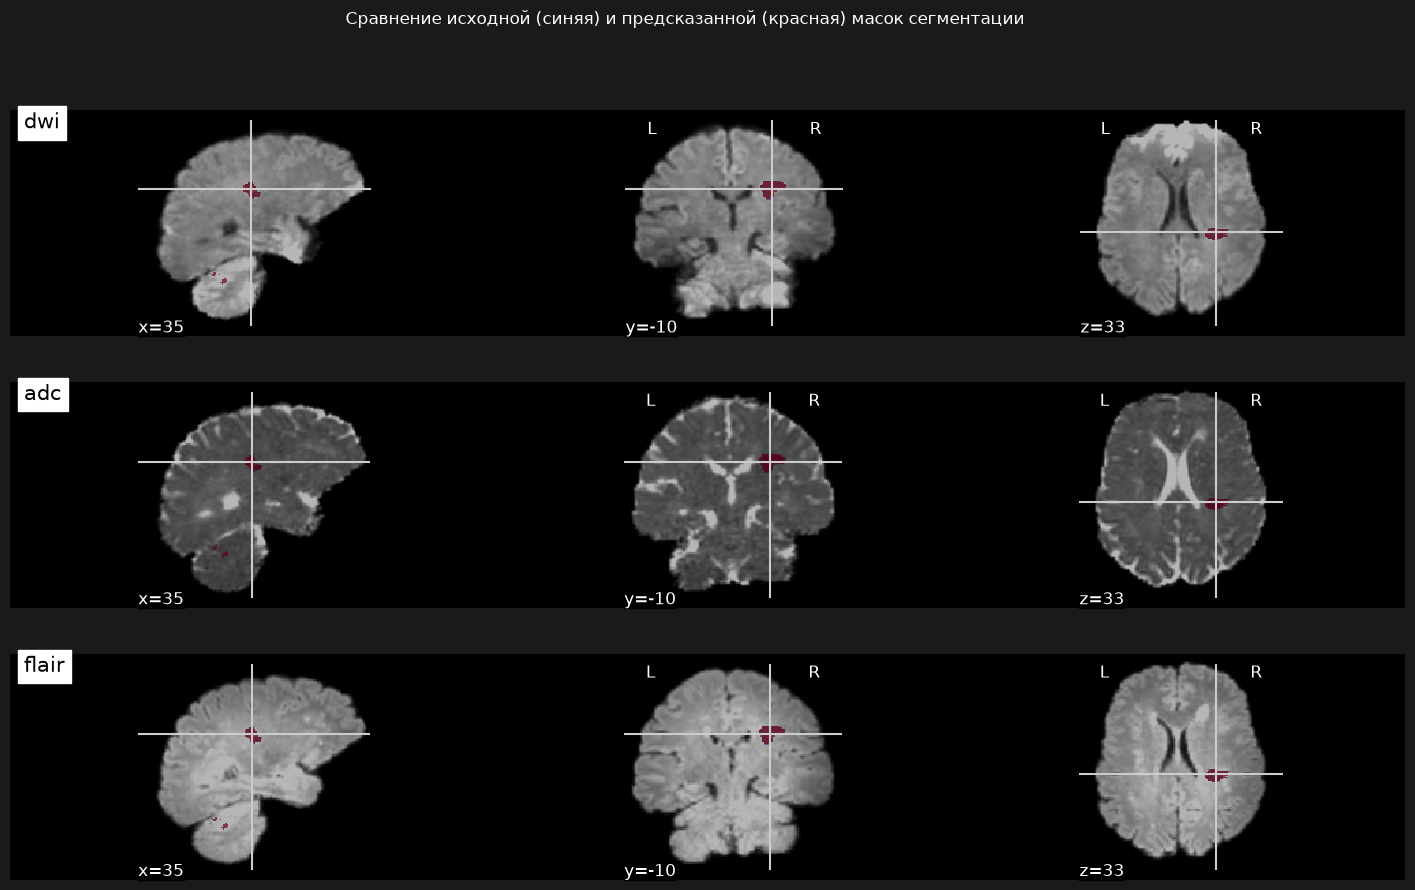

In [10]:
visualize_mri_with_two_mask(large_lesions_model, test_df, best_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)

#### Худшие случаи сегментации

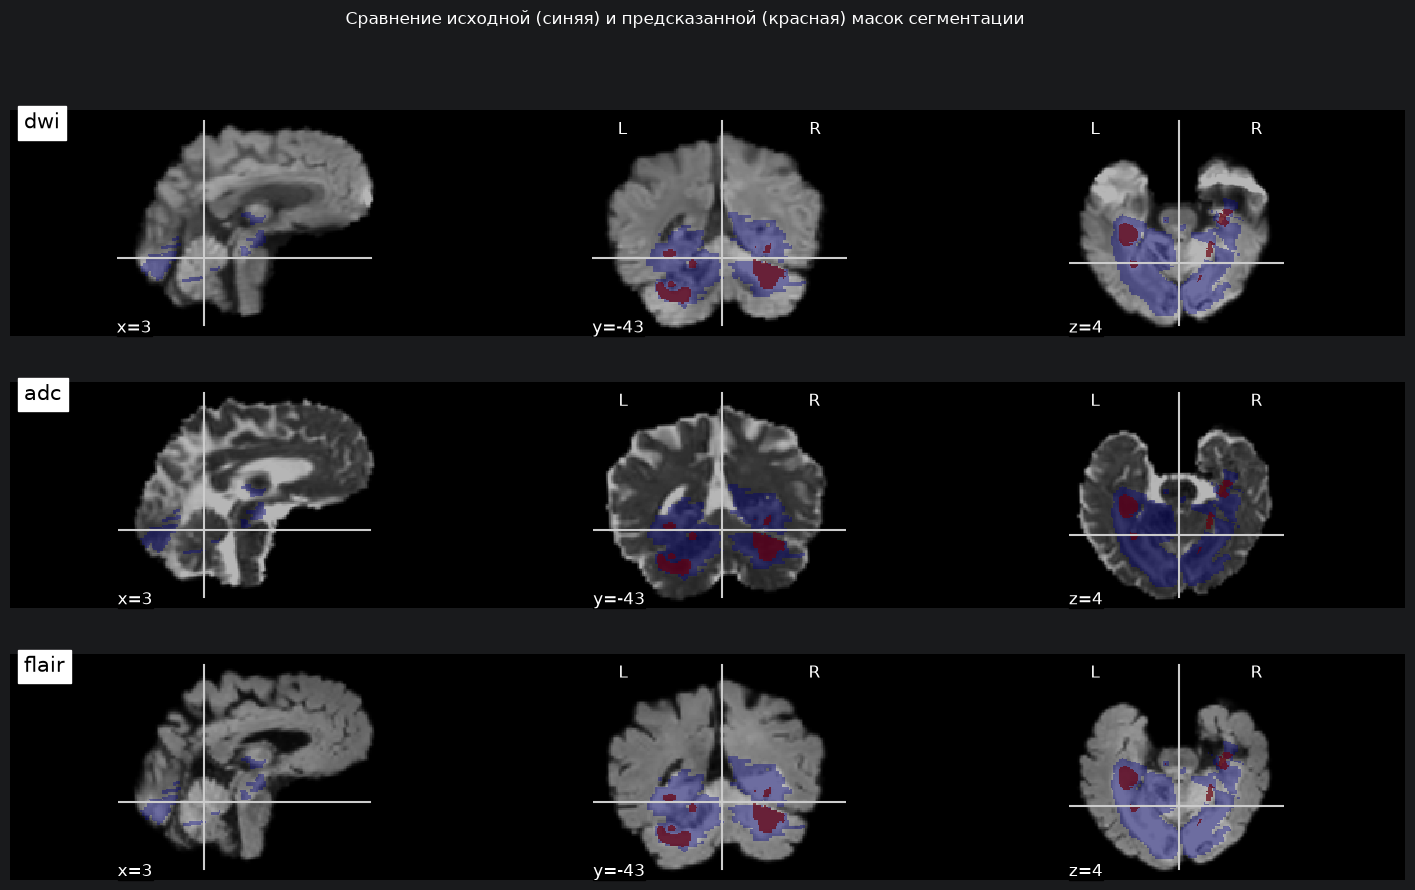

In [11]:
visualize_mri_with_two_mask(large_lesions_model, test_df, worst_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)

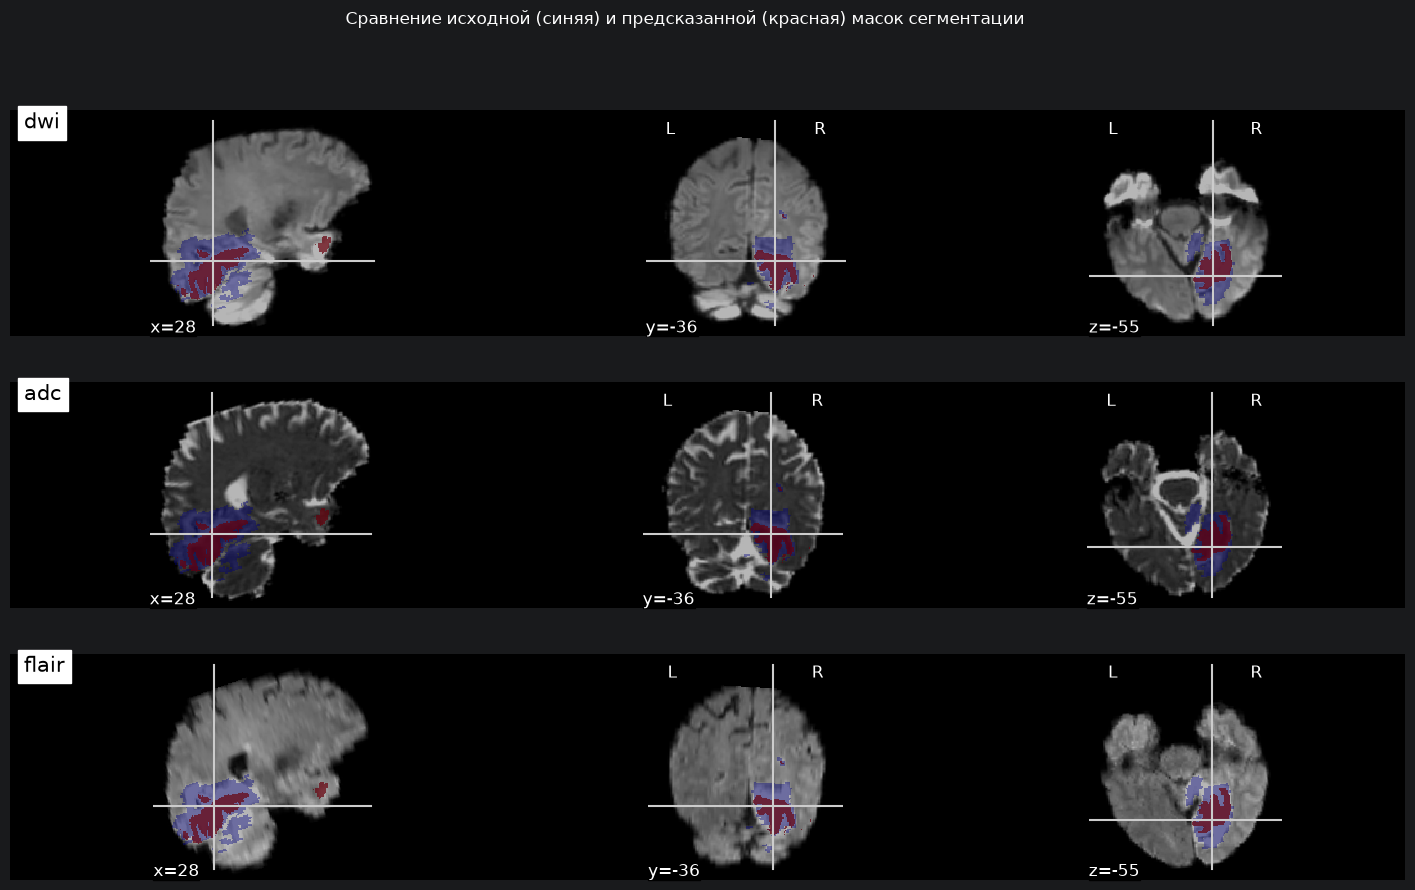

In [12]:
visualize_mri_with_two_mask(large_lesions_model, test_df, worst_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)

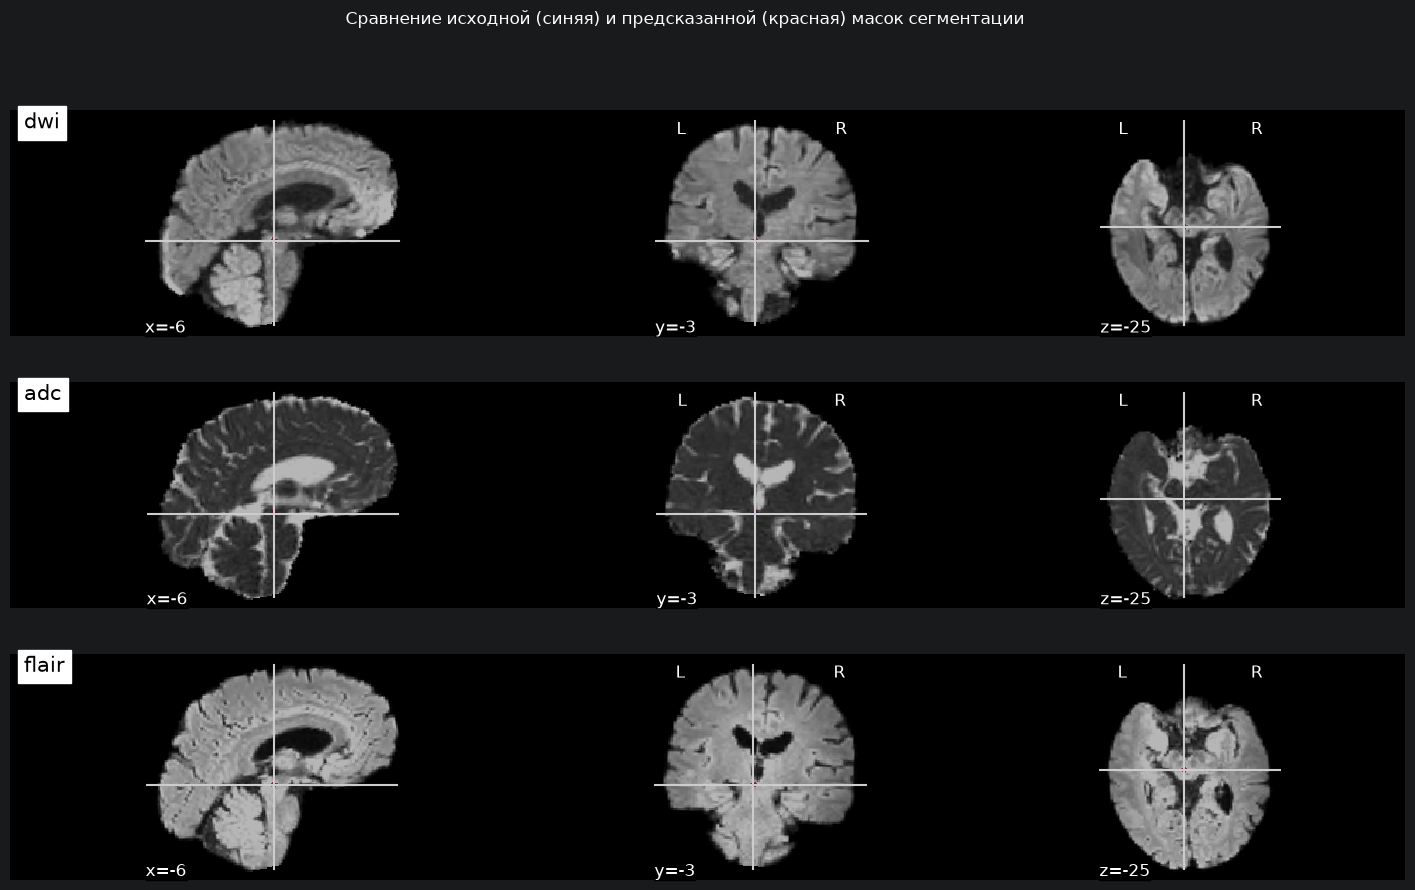

In [13]:
visualize_mri_with_two_mask(large_lesions_model, test_df, worst_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold, small_lesions_model)